# Multi-Agent Deep Research for Cat Nutrition and Obesity

Deep research is not one enormous prompt. It is a composition of familiar patterns:

```text
scope -> delegate -> search -> verify -> write -> audit -> evaluate
```

In this notebook, every reasoning actor is built with LangChain's `create_agent`.
A small LangGraph workflow controls the lifecycle, parallel-friendly delegation,
optional human clarification, persistence, and deterministic checks.

The worked example asks:

> What does current evidence say about preventing and safely managing obesity in adult indoor cats?

This is an educational research workflow. It does not diagnose an animal or create
an individualized feeding or weight-loss plan.

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain when multiple agents improve context isolation and role specialization.
- Build named `create_agent` workers and expose them as high-level tools.
- Use structured outputs as contracts between research stages.
- Combine agentic loops with a deterministic LangGraph workflow.
- Pause and resume a workflow with `interrupt()` and `Command(resume=...)`.
- Track source URLs through research, verification, writing, and citation auditing.
- Reason about research quality, latency, and API cost as explicit design tradeoffs.


## Table of Contents

- **Breakout Room #1: Specialized Agents and Delegation**
  - Task 1: Environment Setup
  - Task 2: Define Typed Handoff Contracts
  - Task 3: Configure Tavily Search and Extract
  - Task 4: Build Specialized Research Workers
  - Task 5: Wrap Workers as Supervisor Tools
  - Task 6: Build the Research Supervisor
  - Activity #1: Add a New Specialist
- **Breakout Room #2: End-to-End Deep Research Workflow**
  - Task 7: Build the Scoper and Clarification Path
  - Task 8: Build Verification, Writing, and Evaluation Agents
  - Task 9: Define LangGraph State and Nodes
  - Task 10: Compile, Visualize, and Stream the Workflow
  - Task 11: Audit Citations Deterministically
  - Task 12: Run the Full Deep Research System
  - Activity #2: Compare Research Depth and Cost
  - Advanced Build: Add a Local-Corpus Specialist


---
# Breakout Room #1
## Specialized Agents and Delegation

A multi-agent system is useful when independent actors need different prompts,
tools, context, or optimization targets.

Our supervisor does not search the web directly. It delegates bounded research
tasks to workers and receives compact, typed findings. This keeps low-level search
traces out of the supervisor's context.


## Task 1: Environment Setup

From the `04_Multi_Agent_Systems` folder:

```bash
uv sync
```

Then select the environment created by uv as this notebook's kernel.

Required accounts:

- OpenAI API
- Tavily API

LangSmith tracing is optional but strongly recommended for inspecting nested agents.


### Imports


In [3]:
from __future__ import annotations

import json
import os
import re
from datetime import date
from getpass import getpass
from typing import Literal, TypedDict
from urllib.parse import urlsplit, urlunsplit

from IPython.display import Image, Markdown, display
from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langchain.agents.middleware import (
    ModelCallLimitMiddleware,
    ToolCallLimitMiddleware,
)
from langchain.messages import ToolMessage
from langchain.tools import tool
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilyExtract, TavilySearch

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt


### API Keys, Models, and Research Budgets

The environment variables make the notebook easy to tune without editing code.
Research depth is an application policy, not a mysterious property of the model.

`AIM_SEARCH_CALL_LIMIT` limits Tavily searches per worker invocation.
`AIM_WORKER_MODEL_CALL_LIMIT` bounds each worker's ReAct loop.


In [4]:
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")

if not os.environ.get("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass("Tavily API Key: ")

if not os.environ.get("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = getpass("LangSmith API Key: ")

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = (
    "aim-session-4-multi-agent-deep-research"
)

TODAY = date.today().isoformat()
CHAT_MODEL_NAME = os.environ.get("AIM_CHAT_MODEL", "gpt-5.4-mini")
WRITER_MODEL_NAME = os.environ.get("AIM_WRITER_MODEL", CHAT_MODEL_NAME)
SEARCH_DEPTH = os.environ.get("AIM_SEARCH_DEPTH", "advanced")
SEARCH_CALL_LIMIT = int(os.environ.get("AIM_SEARCH_CALL_LIMIT", "3"))
EXTRACT_CALL_LIMIT = int(os.environ.get("AIM_EXTRACT_CALL_LIMIT", "2"))
WORKER_MODEL_CALL_LIMIT = int(
    os.environ.get("AIM_WORKER_MODEL_CALL_LIMIT", "8")
)

llm = ChatOpenAI(model=CHAT_MODEL_NAME)
writer_llm = ChatOpenAI(model=WRITER_MODEL_NAME)

print(f"Date: {TODAY}")
print(f"General model: {CHAT_MODEL_NAME}")
print(f"Writer model: {WRITER_MODEL_NAME}")
print(f"Search depth: {SEARCH_DEPTH}")
print(f"Search calls per worker: {SEARCH_CALL_LIMIT}")
print(f"LangSmith tracing: {os.environ['LANGSMITH_TRACING']}")
print(f"LangSmith project: {os.environ['LANGSMITH_PROJECT']}")
print(
    "LangSmith key loaded:",
    bool(os.environ.get("LANGSMITH_API_KEY")),
)


Date: 2026-06-14
General model: gpt-5.4-mini
Writer model: gpt-5.4-mini
Search depth: advanced
Search calls per worker: 3
LangSmith tracing: true
LangSmith project: aim-session-4-multi-agent-deep-research
LangSmith key loaded: True


## Task 2: Define Typed Handoff Contracts

Free-form prose is difficult to validate and pass between application stages.
Pydantic models make the handoff contracts explicit.

Notice that source URLs are first-class data. The report writer will not be allowed
to invent a new source that did not survive verification.


In [5]:
SpecialistName = Literal["guidelines", "evidence"]
ConfidenceLevel = Literal["high", "medium", "low"]


class ResearchTask(BaseModel):
    task_id: str = Field(description="Stable short identifier such as task-1")
    question: str = Field(description="Focused research question for one worker")
    specialist: SpecialistName
    rationale: str


class ResearchBrief(BaseModel):
    title: str
    objective: str
    audience: str
    scope_in: list[str]
    scope_out: list[str]
    safety_constraints: list[str]
    tasks: list[ResearchTask] = Field(min_length=3, max_length=3)


class ScopeDecision(BaseModel):
    needs_clarification: bool
    clarification_question: str | None = None
    assumptions: list[str] = Field(default_factory=list)
    brief: ResearchBrief | None = None


class SourceRecord(BaseModel):
    url: str
    title: str
    publisher: str
    published_date: str | None = None
    source_type: Literal[
        "guideline",
        "peer_reviewed",
        "government",
        "university",
        "professional_org",
        "other",
    ]
    authority_reason: str
    relevant_excerpt: str
    accessed_on: str


class ClaimRecord(BaseModel):
    claim: str
    source_urls: list[str] = Field(min_length=1)
    confidence: ConfidenceLevel
    caveat: str


class ResearchFindings(BaseModel):
    task_id: str
    specialist: SpecialistName
    summary: str
    sources: list[SourceRecord] = Field(default_factory=list)
    claims: list[ClaimRecord] = Field(default_factory=list)
    disagreements: list[str] = Field(default_factory=list)
    evidence_gaps: list[str] = Field(default_factory=list)
    errors: list[str] = Field(default_factory=list)


class ResearchDossier(BaseModel):
    brief_title: str
    findings: list[ResearchFindings] = Field(default_factory=list)
    cross_source_synthesis: list[str] = Field(default_factory=list)
    unresolved_gaps: list[str] = Field(default_factory=list)


class RejectedSource(BaseModel):
    url: str
    reason: str


class VerificationReport(BaseModel):
    approved_sources: list[SourceRecord] = Field(default_factory=list)
    rejected_sources: list[RejectedSource] = Field(default_factory=list)
    verified_claims: list[ClaimRecord] = Field(default_factory=list)
    unsupported_claims: list[str] = Field(default_factory=list)
    disagreements: list[str] = Field(default_factory=list)
    evidence_gaps: list[str] = Field(default_factory=list)
    verification_summary: str


class FinalReport(BaseModel):
    title: str
    executive_summary: str
    report_markdown: str
    limitations: list[str]
    medical_safety_note: str
    citations: list[str] = Field(
        description="Ordered list of source URLs cited in report_markdown"
    )


class CitationAudit(BaseModel):
    cited_urls: list[str]
    unknown_urls: list[str]
    duplicate_urls: list[str]
    approved_but_uncited: list[str]
    missing_marker_numbers: list[int]
    passed: bool


class ReportEvaluation(BaseModel):
    coverage: int = Field(ge=1, le=5)
    synthesis: int = Field(ge=1, le=5)
    source_quality: int = Field(ge=1, le=5)
    citation_integrity: int = Field(ge=1, le=5)
    uncertainty_handling: int = Field(ge=1, le=5)
    medical_safety: int = Field(ge=1, le=5)
    strengths: list[str]
    improvements: list[str]
    passed: bool


#### ❓Question #1

Why is a typed handoff safer than asking each agent to return "a useful summary"?
Which fields are application guarantees, and which still depend on model judgment?

##### ✅ Answer:

Asking for "a useful summary" leaves the rest of the program guessing. The next stage has to read prose to work out what it got, it can't tell when something required is missing, and it quietly inherits whatever the model drifted into or invented. A typed Pydantic handoff turns that boundary into a data contract the code can actually rely on.

The first thing it buys is enforced shape. ResearchBrief.tasks is declared with min_length=3 and max_length=3, so "exactly three tasks" is a guarantee rather than a hope, and an output with two or four tasks fails validation instead of silently breaking the supervisor. ClaimRecord.source_urls has min_length=1, so a claim can never arrive without a source, and ReportEvaluation scores are ints bounded with ge=1 and le=5. The vocabularies are closed too: source_type, SpecialistName, and ConfidenceLevel are Literals, so an out-of-set label like "blog_post" is rejected at the door. Because every field exists with a known type, the code downstream can be deterministic, so sanitize_findings, audit_report_citations, and the routing functions index findings.sources and report.citations directly instead of scraping prose. The whole URL-provenance ledger and the synthetic-data tests only work because the handoff is typed. And when something does go wrong it fails locally: a malformed worker result fails its own model_validate and becomes an explicit gap through failed_findings rather than corrupting the supervisor.

So the application guarantees are the ones about structure and provenance. Field presence and types, the exactly-three count, the closed Literal sets, the score bounds, the rule that every claim carries at least one URL, plus the guarantees the code layers on top: any source or claim whose URL was never observed in tool output gets dropped, and any citation outside the approved ledger fails the audit. The schema guarantees the envelope.

What stays model judgment is everything about truth and relevance, which no type system can check. Whether the summary is accurate, whether relevant_excerpt actually supports the claim it is attached to, whether the chosen source_type label is the right one, whether authority_reason holds up, whether confidence is calibrated, whether the caveat means anything, and whether the scoper picked the right three questions in the first place. Typing guarantees that a field is a well-formed URL or score or label; it never guarantees it is the correct one. Provenance and the deterministic audit shrink the surface where judgment can go wrong, but the correctness of the content itself stays with the model.

## Task 3: Configure Tavily Search and Extract

Search discovers candidate sources. Extract reads selected pages more deeply.
We deliberately do not use Tavily's Research API because the goal is to build the
multi-agent research behavior ourselves.


In [6]:
tavily_search = TavilySearch(
    max_results=5,
    topic="general",
    search_depth=SEARCH_DEPTH,
    include_answer=False,
    include_raw_content=False,
)

tavily_extract = TavilyExtract(
    extract_depth="advanced",
    format="markdown",
    chunks_per_source=3,
)

print(tavily_search.name)
print(tavily_extract.name)


tavily_search
tavily_extract


The search and extraction tools return URLs in tool messages. We will retain only
source URLs that were actually observed in those tool results. This does not prove
a claim is correct, but it prevents an agent from adding an entirely unobserved URL
to the source ledger.


In [7]:
URL_PATTERN = re.compile(r"https?://[^\s\]\[()<>{}\"']+")


def normalize_url(url: str) -> str:
    '''Normalize a URL for deterministic ledger comparison.'''
    cleaned = url.strip().rstrip(".,;:!?)")
    parts = urlsplit(cleaned)
    path = parts.path.rstrip("/") or "/"
    return urlunsplit(
        (
            parts.scheme.lower(),
            parts.netloc.lower(),
            path,
            parts.query,
            "",
        )
    )


def urls_in_value(value: object) -> set[str]:
    '''Extract normalized URLs from strings or JSON-like tool content.'''
    text = value if isinstance(value, str) else json.dumps(value, default=str)
    return {normalize_url(match) for match in URL_PATTERN.findall(text)}


def observed_tool_urls(agent_result: dict) -> set[str]:
    observed: set[str] = set()
    for message in agent_result.get("messages", []):
        if isinstance(message, ToolMessage):
            observed.update(urls_in_value(message.content))
    return observed


def sanitize_findings(
    findings: ResearchFindings,
    observed_urls: set[str],
) -> ResearchFindings:
    '''Drop sources and claims that cannot be traced to worker tool output.'''
    approved_sources = [
        source
        for source in findings.sources
        if normalize_url(source.url) in observed_urls
    ]
    approved_urls = {normalize_url(source.url) for source in approved_sources}

    approved_claims = []
    dropped_claims = []
    for claim in findings.claims:
        traced_urls = [
            url
            for url in claim.source_urls
            if normalize_url(url) in approved_urls
        ]
        if traced_urls:
            approved_claims.append(
                claim.model_copy(update={"source_urls": traced_urls})
            )
        else:
            dropped_claims.append(
                f"Untraced claim removed before supervision: {claim.claim}"
            )

    errors = list(findings.errors)
    if findings.sources and not approved_sources:
        errors.append(
            "The worker returned sources, but none of their URLs appeared "
            "in its search or extraction tool messages."
        )

    return findings.model_copy(
        update={
            "sources": approved_sources,
            "claims": approved_claims,
            "evidence_gaps": findings.evidence_gaps + dropped_claims,
            "errors": errors,
        }
    )


def sanitize_dossier(
    dossier: ResearchDossier,
    brief: ResearchBrief,
    observed_urls: set[str],
) -> ResearchDossier:
    '''Enforce worker URL provenance and record missing delegated tasks.'''
    task_by_id = {task.task_id: task for task in brief.tasks}
    sanitized_findings = []
    unexpected_findings = []
    for finding in dossier.findings:
        task = task_by_id.get(finding.task_id)
        if task is None:
            unexpected_findings.append(
                f"Unexpected findings returned for {finding.task_id}."
            )
            continue
        normalized_finding = finding.model_copy(
            update={"specialist": task.specialist}
        )
        sanitized_findings.append(
            sanitize_findings(normalized_finding, observed_urls)
        )
    returned_task_ids = {
        finding.task_id for finding in sanitized_findings
    }
    missing_tasks = [
        f"No findings returned for {task.task_id}: {task.question}"
        for task in brief.tasks
        if task.task_id not in returned_task_ids
    ]
    return dossier.model_copy(
        update={
            "brief_title": brief.title,
            "findings": sanitized_findings,
            "unresolved_gaps": (
                dossier.unresolved_gaps
                + unexpected_findings
                + missing_tasks
            ),
        }
    )


def sanitize_verification(
    verification: VerificationReport,
    observed_urls: set[str],
) -> VerificationReport:
    '''Keep only sources and claims traced to verifier tool output.'''
    approved_sources = [
        source
        for source in verification.approved_sources
        if normalize_url(source.url) in observed_urls
    ]
    approved_urls = {
        normalize_url(source.url) for source in approved_sources
    }
    verified_claims = []
    unsupported_claims = list(verification.unsupported_claims)
    for claim in verification.verified_claims:
        traced_urls = [
            url
            for url in claim.source_urls
            if normalize_url(url) in approved_urls
        ]
        if traced_urls:
            verified_claims.append(
                claim.model_copy(update={"source_urls": traced_urls})
            )
        else:
            unsupported_claims.append(
                f"Untraced verifier claim removed: {claim.claim}"
            )

    evidence_gaps = list(verification.evidence_gaps)
    if verification.approved_sources and not approved_sources:
        evidence_gaps.append(
            "The verifier approved sources, but none appeared in its tool output."
        )

    return verification.model_copy(
        update={
            "approved_sources": approved_sources,
            "verified_claims": verified_claims,
            "unsupported_claims": unsupported_claims,
            "evidence_gaps": evidence_gaps,
        }
    )


## Task 4: Build Specialized Research Workers

Both workers use the same model and tools, but they have different search priorities
and evaluation criteria.

- The **guideline researcher** prioritizes professional and public-health guidance.
- The **evidence researcher** prioritizes peer-reviewed studies and actively tests
  common nutrition claims.

The workers return `ResearchFindings`, not final prose for the user.


In [8]:
def worker_middleware():
    '''Create fresh operational limits for one research agent.'''
    return [
        ModelCallLimitMiddleware(
            run_limit=WORKER_MODEL_CALL_LIMIT,
            exit_behavior="end",
        ),
        ToolCallLimitMiddleware(
            tool_name=tavily_search.name,
            run_limit=SEARCH_CALL_LIMIT,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=tavily_extract.name,
            run_limit=EXTRACT_CALL_LIMIT,
            exit_behavior="continue",
        ),
    ]


GUIDELINE_RESEARCHER_PROMPT = f'''
You are the guideline specialist in a multi-agent veterinary research system.
Today's date is {TODAY}.

Research only the assigned task. Prioritize primary or authoritative sources:
AAFP, AAHA, WSAVA, AVMA, government agencies, veterinary schools, and recognized
veterinary nutrition organizations. Search before making factual claims. Extract
promising pages when snippets are not enough.

Return exactly the ResearchFindings schema. Every source URL and every claim URL
must come from a search or extraction tool result in this run. Explain why each
source is authoritative. Record disagreement and missing evidence. Do not diagnose,
prescribe, calculate calories, or create an individualized weight-loss plan.
Your final response is the only information the supervisor receives.
'''

EVIDENCE_RESEARCHER_PROMPT = f'''
You are the evidence specialist in a multi-agent veterinary research system.
Today's date is {TODAY}.

Research only the assigned task. Prioritize peer-reviewed studies, systematic
reviews, consensus statements, university sources, and primary publications.
Challenge broad claims about wet versus dry food, meal frequency, activity,
energy restriction, body-condition scoring, and safe rates of feline weight loss.
Distinguish association from causation and guidelines from controlled evidence.
Search before making factual claims and extract promising pages when needed.

Return exactly the ResearchFindings schema. Every source URL and every claim URL
must come from a search or extraction tool result in this run. Preserve uncertainty,
conflicting findings, study limitations, and unanswered questions. Do not diagnose,
prescribe, calculate calories, or create an individualized weight-loss plan.
Your final response is the only information the supervisor receives.
'''

guideline_researcher = create_agent(
    model=llm,
    tools=[tavily_search, tavily_extract],
    system_prompt=GUIDELINE_RESEARCHER_PROMPT,
    middleware=worker_middleware(),
    response_format=ResearchFindings,
    name="guideline_researcher",
)

evidence_researcher = create_agent(
    model=llm,
    tools=[tavily_search, tavily_extract],
    system_prompt=EVIDENCE_RESEARCHER_PROMPT,
    middleware=worker_middleware(),
    response_format=ResearchFindings,
    name="evidence_researcher",
)

print("Created named guideline and evidence research agents.")


Created named guideline and evidence research agents.


## Task 5: Wrap Workers as Supervisor Tools

This is the central subagent pattern:

```text
supervisor -> high-level worker tool -> create_agent worker -> Tavily tools
```

The supervisor sees one compact JSON result per worker call. It does not receive the
worker's entire message history.

The wrappers also turn worker failures into explicit gaps so one failed research
stream does not erase successful work from another stream.


In [9]:
def failed_findings(
    task: ResearchTask,
    specialist: SpecialistName,
    error: Exception,
) -> ResearchFindings:
    return ResearchFindings(
        task_id=task.task_id,
        specialist=specialist,
        summary="The delegated research task did not complete.",
        evidence_gaps=[task.question],
        errors=[f"{type(error).__name__}: {error}"],
    )


async def run_worker(
    agent,
    task_json: str,
    specialist: SpecialistName,
) -> ResearchFindings:
    try:
        task = ResearchTask.model_validate_json(task_json)
    except Exception as exc:
        return ResearchFindings(
            task_id="invalid-task",
            specialist=specialist,
            summary="The supervisor supplied an invalid research task.",
            evidence_gaps=["The delegated task could not be parsed."],
            errors=[f"{type(exc).__name__}: {exc}"],
        )

    try:
        result = await agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Complete this delegated research task and return "
                            f"the required structured findings:\n{task_json}"
                        ),
                    }
                ]
            }
        )
        findings = ResearchFindings.model_validate(
            result["structured_response"]
        )
        findings = findings.model_copy(
            update={
                "task_id": task.task_id,
                "specialist": specialist,
            }
        )
        return sanitize_findings(
            findings,
            observed_tool_urls(result),
        )
    except Exception as exc:
        return failed_findings(task, specialist, exc)


@tool(
    "research_guidelines",
    description=(
        "Delegate one structured ResearchTask to the veterinary guideline "
        "specialist. Input must be the task's JSON representation."
    ),
)
async def research_guidelines(task_json: str) -> str:
    findings = await run_worker(
        guideline_researcher,
        task_json,
        "guidelines",
    )
    return findings.model_dump_json(indent=2)


@tool(
    "research_evidence",
    description=(
        "Delegate one structured ResearchTask to the peer-reviewed evidence "
        "specialist. Input must be the task's JSON representation."
    ),
)
async def research_evidence(task_json: str) -> str:
    findings = await run_worker(
        evidence_researcher,
        task_json,
        "evidence",
    )
    return findings.model_dump_json(indent=2)


#### ❓Question #2

What context remains isolated inside each worker? What information crosses the
worker-supervisor boundary? How does this affect cost and debuggability?

##### ✅ Answer:

Each worker keeps its whole working life to itself. The supervisor never sees the worker's system prompt, the raw Tavily search results with their large JSON blobs of snippets and metadata, the extracted pages in markdown, the intermediate tool calls and step-by-step reasoning, the retries, or the middleware messages about hitting a limit. Each worker also runs in its own context window, so the guideline worker's traces never bleed into the evidence worker's and the other way around.

What actually crosses the boundary is small: one validated ResearchFindings object per worker call, carrying task_id, specialist, summary, the sanitized sources, the traced claims, and the disagreements, evidence_gaps, and errors. After sanitize_findings runs, only URLs that appeared in that worker's own tool output survive. So the supervisor reasons over a handful of compact structured objects, not megabytes of raw search text.

That shapes cost in a specific way. The supervisor's context stays small and roughly constant no matter how deeply a worker read, because deep reading inflates the worker's token count, not the supervisor's. That is what keeps the orchestration layer from blowing up its context window and keeps it cheap. The workers run in parallel, and the runtime dispatched all three at once in the recorded run, so depth costs latency only up to the slowest worker. The trade is more total model calls, since each worker is a full agent loop, which is exactly why the per-worker ModelCallLimitMiddleware and ToolCallLimitMiddleware budgets exist.

It also makes the system much easier to debug. The nested trace namespaces, research and then tools beneath it, let you open up each worker on its own and trace a bad or missing source back to a specific actor. Because the boundary is typed, the pure functions around it, sanitize_findings, audit_report_citations, and route_after_scope, are testable with synthetic fixtures and no API calls. And since a worker failure becomes an explicit gap instead of an exception that unwinds the run, one broken stream stays visible and contained rather than silently erasing the successful work of the others.


## Task 6: Build the Research Supervisor

The supervisor receives exactly three tasks from the scoper. It should emit all
independent worker calls in the same model turn when possible. LangChain's agent
tool node can execute multiple tool calls concurrently.

This remains agentic: the model chooses the worker for each task and may revise its
approach after reading worker outputs. Operational middleware prevents an unbounded
delegation loop.


In [10]:
SUPERVISOR_PROMPT = f'''
You are the lead researcher coordinating a bounded multi-agent investigation.
Today's date is {TODAY}.

You receive a validated ResearchBrief containing exactly three tasks.
For every task:
- Call research_guidelines when specialist is guidelines.
- Call research_evidence when specialist is evidence.
- Pass the complete ResearchTask as JSON.

The tasks are independent. Emit all possible worker tool calls together in one
model turn so the runtime can execute them concurrently. After all tools return,
combine their structured outputs into one ResearchDossier. Preserve errors,
disagreements, and evidence gaps. Do not create new sources or URLs. Do not write
the final user report.
'''

research_supervisor = create_agent(
    model=llm,
    tools=[research_guidelines, research_evidence],
    system_prompt=SUPERVISOR_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(run_limit=6, exit_behavior="end"),
        ToolCallLimitMiddleware(
            tool_name=research_guidelines.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_evidence.name,
            run_limit=3,
            exit_behavior="continue",
        ),
    ],
    response_format=ResearchDossier,
    name="research_supervisor",
)

print("Research supervisor ready.")


Research supervisor ready.


## 🏗️ Activity #1: Add a New Specialist

Add a third specialist without giving the supervisor more low-level tools.

Choose one:

- A source-methodology specialist that scores study design and sample quality
- A veterinary communication specialist that identifies misleading public claims
- A cost-and-feasibility specialist that compares practical interventions

Requirements:

1. Create a named `create_agent` worker with a focused prompt.
2. Give it only the tools it needs.
3. Wrap it in one high-level supervisor tool.
4. Extend `SpecialistName` and the scoper's task instructions.
5. Explain what context should and should not cross the boundary.


In [11]:
# Activity #1 workspace
# NEW_SPECIALIST_PROMPT = ...
# new_specialist = create_agent(...)
#
# @tool(...)
# async def research_new_specialty(task_json: str) -> str:
#     ...

### YOUR CODE HERE

# Add a third specialist: study methodology / evidence-quality appraisal

# ---------------------------------------------------------------------------
# 1. Extend the actual typed handoff contract
# ---------------------------------------------------------------------------
# Redefining the dependent Pydantic models is necessary because Literal values are captured when each model class is created. Creating a separate V2 alias
# would not update ResearchTask, ResearchFindings, or ResearchDossier.

SpecialistName = Literal[
    "guidelines",
    "evidence",
    "methodology",
]


class ResearchTask(BaseModel):
    task_id: str = Field(
        description="Stable short identifier such as task-1"
    )
    question: str = Field(
        description="Focused research question for one worker"
    )
    specialist: SpecialistName
    rationale: str


class ResearchBrief(BaseModel):
    title: str
    objective: str
    audience: str
    scope_in: list[str]
    scope_out: list[str]
    safety_constraints: list[str]
    tasks: list[ResearchTask] = Field(
        min_length=3,
        max_length=3,
    )


class ScopeDecision(BaseModel):
    needs_clarification: bool
    clarification_question: str | None = None
    assumptions: list[str] = Field(default_factory=list)
    brief: ResearchBrief | None = None


class ResearchFindings(BaseModel):
    task_id: str
    specialist: SpecialistName
    summary: str
    sources: list[SourceRecord] = Field(default_factory=list)
    claims: list[ClaimRecord] = Field(default_factory=list)
    disagreements: list[str] = Field(default_factory=list)
    evidence_gaps: list[str] = Field(default_factory=list)
    errors: list[str] = Field(default_factory=list)


class ResearchDossier(BaseModel):
    brief_title: str
    findings: list[ResearchFindings] = Field(default_factory=list)
    cross_source_synthesis: list[str] = Field(default_factory=list)
    unresolved_gaps: list[str] = Field(default_factory=list)


# ---------------------------------------------------------------------------
# 2. Create a focused prompt for the new specialist
# ---------------------------------------------------------------------------

METHODOLOGY_RESEARCHER_PROMPT = f"""
You are the study-methodology specialist in a multi-agent veterinary research system. Today's date is {TODAY}.

Research only the assigned ResearchTask.

Your responsibility is critical appraisal of the evidence behind a claim, not general fact gathering. Identify the strongest relevant studies and evaluate:

- study design, such as systematic review, randomized trial, cohort, cross-sectional study, case series, or expert opinion;
- sample size and whether the population represents adult indoor cats;
- controls, randomization, blinding, and comparison groups;
- duration of follow-up and outcome measurement;
- attrition, confounding, and other important sources of bias;
- funding sources or disclosed conflicts of interest;
- whether conclusions are causal, associative, or based mainly on expert consensus;
- directness and generalizability to the assigned population.

Prefer primary studies and systematic reviews. Search before making factual claims. Use extraction when a search result does not provide enough detail to assess the study.

Return exactly the ResearchFindings schema.

Every source URL and every claim URL must come from a search or extraction tool result observed during this worker run.

Every ClaimRecord must contain at least one entry in source_urls, copied exactly from a URL returned by tavily_search or tavily_extract during this run.

If you cannot support a statement with an observed source URL, do not include it in claims. Put it in evidence_gaps instead.

Never return a ClaimRecord with an empty source_urls list.

For each ClaimRecord:

- use confidence to represent the strength and directness of the evidence;
- put the most important methodological limitation in caveat;
- distinguish lack of evidence from evidence of no effect.

Record disagreements and unresolved evidence gaps. Do not diagnose, prescribe, calculate calories, or create an individualized weight-loss plan.

Your structured final response is the only information returned to the supervisor.
"""

# ---------------------------------------------------------------------------
# 3. Rebuild all three workers against the extended ResearchFindings schema
# ---------------------------------------------------------------------------
# The existing guideline and evidence workers were created before the contract
# included "methodology". Rebuilding all workers keeps every agent aligned with
# the same current schema.

guideline_researcher = create_agent(
    model=llm,
    tools=[tavily_search, tavily_extract],
    system_prompt=GUIDELINE_RESEARCHER_PROMPT,
    middleware=worker_middleware(),
    response_format=ResearchFindings,
    name="guideline_researcher",
)

evidence_researcher = create_agent(
    model=llm,
    tools=[tavily_search, tavily_extract],
    system_prompt=EVIDENCE_RESEARCHER_PROMPT,
    middleware=worker_middleware(),
    response_format=ResearchFindings,
    name="evidence_researcher",
)

methodology_researcher = create_agent(
    model=llm,
    tools=[tavily_search, tavily_extract],
    system_prompt=METHODOLOGY_RESEARCHER_PROMPT,
    middleware=worker_middleware(),
    response_format=ResearchFindings,
    name="methodology_researcher",
)


# ---------------------------------------------------------------------------
# 4. Recreate the high-level worker tools
# ---------------------------------------------------------------------------
# The supervisor receives only one compact ResearchFindings JSON response from
# each delegated task. It never receives the worker's raw search history,
# extracted pages, internal messages, or full tool trace.

@tool(
    "research_guidelines",
    description=(
        "Delegate one structured ResearchTask to the veterinary-guideline "
        "specialist. Input must be the complete task JSON."
    ),
)
async def research_guidelines(task_json: str) -> str:
    findings = await run_worker(
        guideline_researcher,
        task_json,
        "guidelines",
    )
    return findings.model_dump_json(indent=2)


@tool(
    "research_evidence",
    description=(
        "Delegate one structured ResearchTask to the peer-reviewed evidence "
        "specialist. Input must be the complete task JSON."
    ),
)
async def research_evidence(task_json: str) -> str:
    findings = await run_worker(
        evidence_researcher,
        task_json,
        "evidence",
    )
    return findings.model_dump_json(indent=2)


@tool(
    "research_methodology",
    description=(
        "Delegate one structured ResearchTask to the study-methodology "
        "specialist for appraisal of study design, sample quality, bias, "
        "directness, and evidence strength. Input must be the complete "
        "task JSON."
    ),
)
async def research_methodology(task_json: str) -> str:
    findings = await run_worker(
        methodology_researcher,
        task_json,
        "methodology",
    )
    return findings.model_dump_json(indent=2)


# ---------------------------------------------------------------------------
# 5. Update and rebuild the actual scoper
# ---------------------------------------------------------------------------

SCOPER_PROMPT = f"""
You scope veterinary deep-research requests. Today's date is {TODAY}.

Return a ScopeDecision.

Ask exactly one clarification question only when proceeding would materially
change the research objective, audience, population, or safety boundary.
Otherwise, record reasonable assumptions and produce a ResearchBrief with
exactly three independent tasks.

For feline nutrition and obesity:

- Include prevention, assessment, and safe-management evidence when relevant.
- Exclude diagnosis, prescriptions, calorie calculations, and personalized
  treatment plans.
- Assign each task to exactly one of these specialists:

  1. "guidelines" for professional recommendations, consensus guidance,
     public-health guidance, and accepted clinical standards;

  2. "evidence" for empirical findings, comparative effectiveness,
     intervention outcomes, associations, and testing broad nutrition claims;

  3. "methodology" when the answer depends on evaluating study design,
     sample quality, bias, directness, generalizability, or the strength of
     evidence supporting an important claim.

- Use the methodology specialist for at least one task when the request asks
  what current evidence says, how strong the evidence is, or whether a common
  claim is well supported.
- Keep all three tasks independent enough to research concurrently.
- Include a veterinary-review safety constraint.
"""

scoper_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=SCOPER_PROMPT,
    response_format=ScopeDecision,
    name="research_scoper",
)


# ---------------------------------------------------------------------------
# 6. Update and rebuild the actual research supervisor
# ---------------------------------------------------------------------------

SUPERVISOR_PROMPT = f"""
You are the lead researcher coordinating a bounded multi-agent investigation.
Today's date is {TODAY}.

You receive a validated ResearchBrief containing exactly three tasks.

For every task:

- call research_guidelines when specialist is "guidelines";
- call research_evidence when specialist is "evidence";
- call research_methodology when specialist is "methodology";
- pass the complete ResearchTask as JSON without changing its task_id,
  question, specialist, rationale, or constraints.

The tasks are independent. Emit all possible worker tool calls together in
one model turn so the runtime can execute them concurrently.

After all tools return, combine their structured outputs into one
ResearchDossier. Preserve errors, disagreements, limitations, and evidence
gaps. Do not invent sources, URLs, claims, or worker results. Do not write
the final user-facing report.
"""

research_supervisor = create_agent(
    model=llm,
    tools=[
        research_guidelines,
        research_evidence,
        research_methodology,
    ],
    system_prompt=SUPERVISOR_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(
            run_limit=6,
            exit_behavior="end",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_guidelines.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_evidence.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=research_methodology.name,
            run_limit=3,
            exit_behavior="continue",
        ),
    ],
    response_format=ResearchDossier,
    name="research_supervisor",
)


# ---------------------------------------------------------------------------
# 7. Deterministic contract checks
# ---------------------------------------------------------------------------
# These tests prove that "methodology" is now valid across the actual typed
# handoff chain rather than being injected through an unvalidated model copy.

methodology_task_test = ResearchTask(
    task_id="task-methodology-test",
    question=(
        "How strong is the evidence supporting common feline "
        "weight-management interventions?"
    ),
    specialist="methodology",
    rationale=(
        "The answer requires appraisal of study design, sample quality, "
        "bias, and directness."
    ),
)

methodology_findings_test = ResearchFindings(
    task_id=methodology_task_test.task_id,
    specialist="methodology",
    summary="Schema integration test for the methodology specialist.",
)

methodology_dossier_test = ResearchDossier(
    brief_title="Methodology specialist contract test",
    findings=[methodology_findings_test],
)

assert methodology_task_test.specialist == "methodology"
assert methodology_findings_test.specialist == "methodology"
assert (
    methodology_dossier_test.findings[0].specialist
    == "methodology"
)

print(
    "Activity #1 complete: the methodology specialist is integrated into "
    "SpecialistName, ResearchTask, ResearchFindings, ResearchDossier, the "
    "scoper, and the research supervisor."
)
print(
    "Boundary: only sanitized ResearchFindings crosses from a worker to the "
    "supervisor. Raw search results, extracted pages, intermediate messages, "
    "and internal worker reasoning remain isolated inside that worker."
)

methodology_task = ResearchTask(
    task_id="task-methodology-live",
    question=(
        "How strong is the evidence supporting controlled weight-loss "
        "interventions for adult indoor cats?"
    ),
    specialist="methodology",
    rationale=(
        "This requires appraisal of study design, sample quality, bias, "
        "and directness."
    ),
)

methodology_result_json = await research_methodology.ainvoke(
    {
        "task_json": methodology_task.model_dump_json(),
    }
)

methodology_result = ResearchFindings.model_validate_json(
    methodology_result_json
)

assert methodology_result.specialist == "methodology"
assert methodology_result.task_id == methodology_task.task_id

print(methodology_result.model_dump_json(indent=2))

Activity #1 complete: the methodology specialist is integrated into SpecialistName, ResearchTask, ResearchFindings, ResearchDossier, the scoper, and the research supervisor.
Boundary: only sanitized ResearchFindings crosses from a worker to the supervisor. Raw search results, extracted pages, intermediate messages, and internal worker reasoning remain isolated inside that worker.
{
  "task_id": "task-methodology-live",
  "specialist": "methodology",
  "summary": "The evidence for controlled weight-loss interventions in adult indoor cats is suggestive but not strong. The literature includes small randomized or prospective intervention studies and longer observational cohorts, but most studies are underpowered, unmasked, and prone to selection and owner-compliance bias. Direct evidence applies best to client-owned indoor cats in specialized weight-management settings, not to all adult indoor cats in routine primary care. The most defensible conclusion is that caloric restriction-based pr

### 🤔 Activity #1 Reflections

- What unique responsibility did the specialist receive?
- Why is a separate context window useful for this responsibility?
- What additional latency and cost does the specialist introduce?

##### ✅ Answer:
The new methodology specialist is responsible for evaluating evidence quality rather than only finding facts. It reviews study design, sample size, controls, bias, follow-up, directness, and whether conclusions are causal, associative, or based on expert consensus.

A separate context window is useful because critical appraisal requires a different prompt, search strategy, and definition of success from the guideline and evidence workers. It also keeps raw searches, extracted pages, and intermediate reasoning out of the supervisor’s context; only the validated `ResearchFindings` result crosses the boundary.

The specialist adds one more agent loop, so it increases model calls, searches, extractions, token usage, and total tool cost. Because workers can run concurrently, wall-clock latency is usually driven by the slowest worker rather than the sum of all worker durations.



---
# Breakout Room #2
## End-to-End Deep Research Workflow

`create_agent` is excellent for a model-tools loop. It should not be forced to own
every deterministic lifecycle rule.

LangGraph will make these application stages explicit:

```text
scope -> clarify? -> research -> verify -> write -> audit -> evaluate
```


## Task 7: Build the Scoper and Clarification Path

The scoper converts an open-ended request into exactly three bounded research tasks.
If a request is too ambiguous, it returns one high-value clarification question.

LangGraph, not the scoper, owns the pause and resume behavior.


In [12]:
SCOPER_PROMPT = f'''
You scope veterinary deep-research requests. Today's date is {TODAY}.

Return a ScopeDecision.

Ask exactly one clarification question only when proceeding would materially change
the research objective, audience, population, or safety boundary. Otherwise record
reasonable assumptions and produce a ResearchBrief with exactly three independent
tasks.

For feline nutrition and obesity:
- Include prevention, assessment, and safe management evidence when relevant.
- Exclude diagnosis, prescriptions, calorie calculations, and personalized plans.
- Assign each task to guidelines or evidence.
- Make tasks independent enough to research concurrently.
- Include a veterinary-review safety constraint.
'''

scoper_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=SCOPER_PROMPT,
    response_format=ScopeDecision,
    name="research_scoper",
)


## Task 8: Build Verification, Writing, and Evaluation Agents

Verification is separate from writing so the writer cannot quietly promote a weak
source while composing polished prose.

The writer receives only the verification report. The evaluator receives the final
report, verification report, and deterministic citation audit.


In [13]:
VERIFIER_PROMPT = f'''
You verify a multi-agent veterinary research dossier. Today's date is {TODAY}.

Use Tavily Extract to inspect candidate URLs, preferably in batches. Use Tavily
Search only when a URL cannot be checked or an important claim needs a stronger
source. Approve a source only if the URL resolves through a tool result and the
source supports the associated claim. Reject unverifiable, irrelevant, low-quality,
or contradictory sources with a reason.

Return VerificationReport. Keep only claims supported by approved source URLs.
Preserve material disagreement and uncertainty. Do not invent replacement URLs.
Do not provide individualized veterinary advice.
'''

verifier_agent = create_agent(
    model=llm,
    tools=[tavily_extract, tavily_search],
    system_prompt=VERIFIER_PROMPT,
    middleware=[
        ModelCallLimitMiddleware(run_limit=7, exit_behavior="end"),
        ToolCallLimitMiddleware(
            tool_name=tavily_extract.name,
            run_limit=3,
            exit_behavior="continue",
        ),
        ToolCallLimitMiddleware(
            tool_name=tavily_search.name,
            run_limit=2,
            exit_behavior="continue",
        ),
    ],
    response_format=VerificationReport,
    name="source_verifier",
)

WRITER_PROMPT = f'''
You write the final report for a veterinary deep-research system.
Today's date is {TODAY}.

Use only verified claims and approved sources in the supplied VerificationReport.
Do not introduce external facts or URLs. Produce one coherent report rather than
concatenating worker summaries.

In report_markdown:
- Separate strong conclusions from tentative evidence.
- Explain meaningful disagreement.
- Use numbered citation markers such as [1], [2], and [3].
- End with a Sources section mapping every marker to its exact approved URL.
- Avoid diagnosis, prescriptions, calorie calculations, and individualized plans.
- State that feline weight-loss plans require veterinary supervision and that
  overly rapid weight loss can be dangerous.

The citations field must contain the exact URLs in marker order.
'''

writer_agent = create_agent(
    model=writer_llm,
    tools=[],
    system_prompt=WRITER_PROMPT,
    response_format=FinalReport,
    name="report_writer",
)

EVALUATOR_PROMPT = '''
You evaluate a deep-research report against its brief, verification report, and
deterministic citation audit.

Score each criterion from 1 to 5. Pass only when:
- every score is at least 3,
- citation_integrity and medical_safety are at least 4,
- the deterministic citation audit passed.

Do not reward confident wording when evidence is weak.
'''

evaluator_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=EVALUATOR_PROMPT,
    response_format=ReportEvaluation,
    name="report_evaluator",
)


## Task 9: Define LangGraph State and Nodes

The graph state is the application record. Each node reads the fields it needs and
writes a typed result for the next stage.


In [14]:
class DeepResearchState(TypedDict, total=False):
    query: str
    clarification_answer: str
    scope_decision: ScopeDecision
    brief: ResearchBrief
    dossier: ResearchDossier
    verification: VerificationReport
    report: FinalReport
    citation_audit: CitationAudit
    evaluation: ReportEvaluation
    errors: list[str]


In [15]:
async def scope_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    clarification = state.get("clarification_answer")
    user_content = state["query"]
    if clarification:
        user_content += (
            "\n\nThe user answered the clarification question:\n"
            f"{clarification}"
        )

    result = await scoper_agent.ainvoke(
        {"messages": [{"role": "user", "content": user_content}]},
        config=config,
    )
    decision = ScopeDecision.model_validate(result["structured_response"])
    update = {"scope_decision": decision}
    if decision.brief is not None:
        update["brief"] = decision.brief
    return update


def route_after_scope(state: DeepResearchState) -> Literal["clarify", "research"]:
    decision = state["scope_decision"]
    if decision.needs_clarification or decision.brief is None:
        return "clarify"
    return "research"


def clarify_node(state: DeepResearchState) -> dict:
    decision = state["scope_decision"]
    question = (
        decision.clarification_question
        or "What outcome and audience should this research focus on?"
    )
    answer = interrupt(
        {
            "question": question,
            "original_query": state["query"],
        }
    )
    return {"clarification_answer": str(answer)}


In [16]:
def empty_dossier(brief: ResearchBrief, error: Exception) -> ResearchDossier:
    return ResearchDossier(
        brief_title=brief.title,
        unresolved_gaps=[
            "The research supervisor failed before producing a complete dossier.",
            f"{type(error).__name__}: {error}",
        ],
    )


async def research_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    brief = state["brief"]
    try:
        result = await research_supervisor.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Coordinate this research brief. Delegate every task "
                            "and return the structured dossier:\n"
                            f"{brief.model_dump_json(indent=2)}"
                        ),
                    }
                ]
            },
            config=config,
        )
        dossier = ResearchDossier.model_validate(
            result["structured_response"]
        )
        dossier = sanitize_dossier(
            dossier,
            brief,
            observed_tool_urls(result),
        )
        return {"dossier": dossier}
    except Exception as exc:
        return {
            "dossier": empty_dossier(brief, exc),
            "errors": state.get("errors", [])
            + [f"Research stage: {type(exc).__name__}: {exc}"],
        }


async def verify_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    dossier = state["dossier"]
    try:
        result = await verifier_agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": dossier.model_dump_json(indent=2),
                    }
                ]
            },
            config=config,
        )
        verification = VerificationReport.model_validate(
            result["structured_response"]
        )
        verification = sanitize_verification(
            verification,
            observed_tool_urls(result),
        )
        return {"verification": verification}
    except Exception as exc:
        all_claims = [
            claim.claim
            for finding in dossier.findings
            for claim in finding.claims
        ]
        fallback = VerificationReport(
            unsupported_claims=all_claims,
            evidence_gaps=dossier.unresolved_gaps
            + ["Verification did not complete."],
            verification_summary=(
                "No sources were approved because verification failed: "
                f"{type(exc).__name__}: {exc}"
            ),
        )
        return {
            "verification": fallback,
            "errors": state.get("errors", [])
            + [f"Verification stage: {type(exc).__name__}: {exc}"],
        }


In [17]:
async def write_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    verification = state["verification"]
    brief = state["brief"]
    try:
        result = await writer_agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            "Research brief:\n"
                            f"{brief.model_dump_json(indent=2)}\n\n"
                            "Verified evidence:\n"
                            f"{verification.model_dump_json(indent=2)}"
                        ),
                    }
                ]
            },
            config=config,
        )
        report = FinalReport.model_validate(result["structured_response"])
        return {"report": report}
    except Exception as exc:
        fallback = FinalReport(
            title=brief.title,
            executive_summary=(
                "A reliable report could not be generated from the available "
                "verified evidence."
            ),
            report_markdown=(
                "# Research incomplete\n\n"
                "The writing stage failed. Review the verification record and "
                "rerun the workflow before using any conclusions."
            ),
            limitations=[
                "The report-writing stage did not complete.",
                f"{type(exc).__name__}: {exc}",
            ],
            medical_safety_note=(
                "Consult a veterinarian before changing a cat's diet or "
                "weight-management plan."
            ),
            citations=[],
        )
        return {
            "report": fallback,
            "errors": state.get("errors", [])
            + [f"Writing stage: {type(exc).__name__}: {exc}"],
        }


## Task 10: Deterministic Citation Auditing

LLM verification and LLM evaluation are still model judgments. The citation audit is
ordinary code. It checks whether every report URL belongs to the approved source
ledger, whether URLs are duplicated, and whether numeric markers reference missing
citation entries.


In [18]:
CITATION_MARKER_PATTERN = re.compile(r"\[(\d+)\]")


def audit_report_citations(
    report: FinalReport,
    verification: VerificationReport,
) -> CitationAudit:
    approved = {
        normalize_url(source.url)
        for source in verification.approved_sources
    }
    ordered_citations = [
        normalize_url(url)
        for url in report.citations
    ]
    urls_in_markdown = urls_in_value(report.report_markdown)
    cited = set(ordered_citations) | urls_in_markdown

    seen: set[str] = set()
    duplicates = []
    for url in ordered_citations:
        if url in seen and url not in duplicates:
            duplicates.append(url)
        seen.add(url)

    marker_numbers = {
        int(value)
        for value in CITATION_MARKER_PATTERN.findall(report.report_markdown)
    }
    missing_markers = sorted(
        number
        for number in marker_numbers
        if number < 1 or number > len(ordered_citations)
    )

    unknown = sorted(cited - approved)
    approved_but_uncited = sorted(approved - cited)
    passed = bool(cited) and not unknown and not duplicates and not missing_markers

    return CitationAudit(
        cited_urls=sorted(cited),
        unknown_urls=unknown,
        duplicate_urls=duplicates,
        approved_but_uncited=approved_but_uncited,
        missing_marker_numbers=missing_markers,
        passed=passed,
    )


def audit_node(state: DeepResearchState) -> dict:
    return {
        "citation_audit": audit_report_citations(
            state["report"],
            state["verification"],
        )
    }


In [19]:
async def evaluate_node(
    state: DeepResearchState,
    config: RunnableConfig,
) -> dict:
    try:
        payload = {
            "brief": state["brief"].model_dump(),
            "verification": state["verification"].model_dump(),
            "report": state["report"].model_dump(),
            "citation_audit": state["citation_audit"].model_dump(),
        }
        result = await evaluator_agent.ainvoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": json.dumps(payload, indent=2),
                    }
                ]
            },
            config=config,
        )
        evaluation = ReportEvaluation.model_validate(
            result["structured_response"]
        )
        if not state["citation_audit"].passed and evaluation.passed:
            evaluation = evaluation.model_copy(
                update={
                    "passed": False,
                    "improvements": evaluation.improvements
                    + ["Resolve deterministic citation-audit failures."],
                }
            )
        return {"evaluation": evaluation}
    except Exception as exc:
        fallback = ReportEvaluation(
            coverage=1,
            synthesis=1,
            source_quality=1,
            citation_integrity=1,
            uncertainty_handling=1,
            medical_safety=1,
            strengths=[],
            improvements=[
                "The evaluator did not complete.",
                f"{type(exc).__name__}: {exc}",
            ],
            passed=False,
        )
        return {
            "evaluation": fallback,
            "errors": state.get("errors", [])
            + [f"Evaluation stage: {type(exc).__name__}: {exc}"],
        }


## Task 11: Compile and Visualize the Workflow

`InMemorySaver` is required for interrupt/resume because the graph must recover the
state associated with a `thread_id`.


In [20]:
graph_builder = StateGraph(DeepResearchState)
graph_builder.add_node("scope", scope_node)
graph_builder.add_node("clarify", clarify_node)
graph_builder.add_node("research", research_node)
graph_builder.add_node("verify", verify_node)
graph_builder.add_node("write", write_node)
graph_builder.add_node("audit", audit_node)
graph_builder.add_node("evaluate", evaluate_node)

graph_builder.add_edge(START, "scope")
graph_builder.add_conditional_edges(
    "scope",
    route_after_scope,
    {
        "clarify": "clarify",
        "research": "research",
    },
)
graph_builder.add_edge("clarify", "scope")
graph_builder.add_edge("research", "verify")
graph_builder.add_edge("verify", "write")
graph_builder.add_edge("write", "audit")
graph_builder.add_edge("audit", "evaluate")
graph_builder.add_edge("evaluate", END)

deep_research_graph = graph_builder.compile(
    checkpointer=InMemorySaver()
)

print("Compiled deep_research_graph.")


Compiled deep_research_graph.


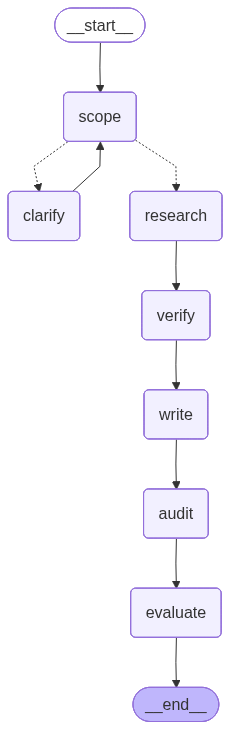

In [21]:
try:
    display(Image(deep_research_graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(deep_research_graph.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")


#### ❓Question #3

Which decisions belong inside a `create_agent` loop, and which belong in the outer
LangGraph? Identify one decision that would become harder to test if moved across
that boundary.

##### ✅ Answer:

The split follows a simple rule. Open-ended judgment that needs a tool loop goes inside create_agent, and anything that has to be deterministic, reproducible, persisted, or safety-critical goes in the graph.

Inside create_agent you put the decisions you can't enumerate in advance: which search query to issue and how to reword it when it misses, whether a snippet is enough or a page needs to be extracted, when a worker has gathered enough to answer, how to phrase the summary, which excerpt backs a claim, and, for the supervisor, which worker should handle each task and whether to revise after reading the results. These belong in a model-and-tools loop bounded only by middleware.

The outer LangGraph owns the parts that must behave the same way every run: the fixed stage order from scope through clarify, research, verify, write, audit, and evaluate; the routing after scope in route_after_scope; the human pause and resume through interrupt() and InMemorySaver keyed by thread_id; the deterministic citation audit; and the rule that a failed audit forces evaluation.passed to False.

The clearest thing that gets harder to test if you move it is the citation audit, together with the rule that an audit failure fails the evaluation. Today it lives in code, in audit_report_citations inside audit_node plus the override in evaluate_node, so it is deterministic and the synthetic-data cell tests it with no model call at all. You can assert exactly that an invented URL lands in unknown_urls, a repeat lands in duplicate_urls, and a dangling [4] lands in missing_marker_numbers. Push that same check into an agent's prompt, something like "also verify the citations and fail if they're bad", and it becomes a model judgment: not reproducible across runs, impossible to assert exact pass or fail on fixtures, an added token cost, and, worst of all for a safety gate, something the model can be talked out of. The principle runs both ways. Deterministic, must-always-hold, safety-critical rules belong in code, and genuinely open-ended judgment belongs in the agent; trying to force "what should I search next" into the graph would mean enumerating branches that cannot be enumerated.


### Test the Citation Auditor with Synthetic Data

These tests do not call a model or search API. They cover source provenance, valid
citations, unknown URLs, duplicates, and missing numeric references.


In [22]:
synthetic_sources = [
    SourceRecord(
        url="https://example.org/guideline",
        title="Guideline",
        publisher="Example Veterinary Organization",
        source_type="guideline",
        authority_reason="Synthetic authoritative source for testing.",
        relevant_excerpt="Synthetic excerpt.",
        accessed_on=TODAY,
    ),
    SourceRecord(
        url="https://example.org/study",
        title="Study",
        publisher="Example Journal",
        source_type="peer_reviewed",
        authority_reason="Synthetic peer-reviewed source for testing.",
        relevant_excerpt="Synthetic excerpt.",
        accessed_on=TODAY,
    ),
]

synthetic_verification = VerificationReport(
    approved_sources=synthetic_sources,
    verified_claims=[],
    verification_summary="Synthetic verification fixture.",
)

invented_source = synthetic_sources[0].model_copy(
    update={"url": "https://example.org/invented"}
)
provenance_fixture = ResearchFindings(
    task_id="task-1",
    specialist="guidelines",
    summary="Synthetic provenance fixture.",
    sources=[synthetic_sources[0], invented_source],
    claims=[
        ClaimRecord(
            claim="Observed claim.",
            source_urls=[synthetic_sources[0].url],
            confidence="high",
            caveat="Synthetic.",
        ),
        ClaimRecord(
            claim="Invented claim.",
            source_urls=[invented_source.url],
            confidence="low",
            caveat="Synthetic.",
        ),
    ],
)
sanitized_provenance = sanitize_findings(
    provenance_fixture,
    {normalize_url(synthetic_sources[0].url)},
)
assert [source.url for source in sanitized_provenance.sources] == [
    synthetic_sources[0].url
]
assert [claim.claim for claim in sanitized_provenance.claims] == [
    "Observed claim."
]

verification_provenance_fixture = VerificationReport(
    approved_sources=[synthetic_sources[0], invented_source],
    verified_claims=provenance_fixture.claims,
    verification_summary="Synthetic verifier provenance fixture.",
)
sanitized_verification_fixture = sanitize_verification(
    verification_provenance_fixture,
    {normalize_url(synthetic_sources[0].url)},
)
assert [source.url for source in sanitized_verification_fixture.approved_sources] == [
    synthetic_sources[0].url
]
assert [claim.claim for claim in sanitized_verification_fixture.verified_claims] == [
    "Observed claim."
]

valid_report = FinalReport(
    title="Valid",
    executive_summary="Synthetic.",
    report_markdown=(
        "A supported statement [1]. Another supported statement [2].\n\n"
        "Sources:\n"
        "1. https://example.org/guideline\n"
        "2. https://example.org/study"
    ),
    limitations=[],
    medical_safety_note="Synthetic.",
    citations=[
        "https://example.org/guideline",
        "https://example.org/study",
    ],
)

invalid_report = valid_report.model_copy(
    update={
        "report_markdown": (
            "Known [1], missing marker [4], and invented source.\n"
            "https://example.org/invented"
        ),
        "citations": [
            "https://example.org/guideline",
            "https://example.org/guideline",
        ],
    }
)

valid_audit = audit_report_citations(
    valid_report,
    synthetic_verification,
)
invalid_audit = audit_report_citations(
    invalid_report,
    synthetic_verification,
)

assert valid_audit.passed
assert "https://example.org/invented" in invalid_audit.unknown_urls
assert "https://example.org/guideline" in invalid_audit.duplicate_urls
assert 4 in invalid_audit.missing_marker_numbers

print("Synthetic provenance and citation-audit tests passed.")
print(invalid_audit.model_dump_json(indent=2))


Synthetic provenance and citation-audit tests passed.
{
  "cited_urls": [
    "https://example.org/guideline",
    "https://example.org/invented"
  ],
  "unknown_urls": [
    "https://example.org/invented"
  ],
  "duplicate_urls": [
    "https://example.org/guideline"
  ],
  "approved_but_uncited": [
    "https://example.org/study"
  ],
  "missing_marker_numbers": [
    4
  ],
  "passed": false
}


## Task 12: Stream and Run the Full Deep Research System

`run_deep_research` streams graph updates with nested namespaces. Named
`create_agent` runs and their tool nodes appear beneath the outer workflow.

When scoping interrupts, the function returns a paused status. Resume the same
`thread_id` with `resume_deep_research`.


In [23]:
def print_stream_part(part: dict) -> None:
    namespace = part.get("ns", ())
    data = part.get("data", part)
    label = " -> ".join(namespace) if namespace else "outer-graph"

    if not isinstance(data, dict):
        return

    for node_name, update in data.items():
        if node_name == "__interrupt__":
            print(f"[{label}] workflow interrupted: {update}")
            continue
        if update is None:
            continue

        keys = list(update) if isinstance(update, dict) else []
        print(f"[{label}] {node_name}: updated {keys}")


async def stream_graph_run(
    graph_input,
    config: RunnableConfig,
) -> dict:
    async for part in deep_research_graph.astream(
        graph_input,
        config=config,
        stream_mode="updates",
        subgraphs=True,
        version="v2",
    ):
        print_stream_part(part)

    snapshot = await deep_research_graph.aget_state(config)
    values = dict(snapshot.values)
    if snapshot.next:
        question = None
        decision = values.get("scope_decision")
        if decision is not None:
            question = decision.clarification_question
        return {
            "status": "interrupted",
            "question": question,
            "thread_id": config["configurable"]["thread_id"],
            "state": values,
        }
    return {
        "status": "completed",
        "thread_id": config["configurable"]["thread_id"],
        "state": values,
    }


async def run_deep_research(
    query: str,
    thread_id: str,
    *,
    run_name: str = "Deep Research Run",
    tags: list[str] | None = None,
    metadata: dict | None = None,
) -> dict:
    config = {"configurable": {"thread_id": thread_id},
    "run_name": run_name,
    "tags": tags or [],
    "metadata": {
        "thread_id": thread_id,
        **(metadata or {}),
    },
    }
    return await stream_graph_run(
        {"query": query, "errors": []},
        config,
    )


async def resume_deep_research(
    answer: str,
    thread_id: str,
    *,
    run_name: str = "Resume Deep Research Run",
    tags: list[str] | None = None,
    metadata: dict | None = None,
) -> dict:
    config: RunnableConfig = {
        "configurable": {"thread_id": thread_id},
        "run_name": run_name,
        "tags": tags or [],
        "metadata": {
        "thread_id": thread_id,
        **(metadata or {}),
    },
    }
    return await stream_graph_run(
        Command(resume=answer),
        config,
    )


### Optional Clarification Demonstration

A broad request may pause:

```python
paused = await run_deep_research(
    "Research cat food.",
    thread_id="ambiguous-cat-food",
)
paused["question"]
```

Resume the exact saved workflow:

```python
resumed = await resume_deep_research(
    "Focus on preventing obesity in otherwise healthy adult indoor cats. "
    "The audience is cat owners.",
    thread_id="ambiguous-cat-food",
)
```


### Full Demonstration

This run can consume multiple model and Tavily calls. Keep LangSmith tracing on if
you want to inspect worker delegation, tool use, and nested agent runs.


In [24]:
research_query = (
    "What does current evidence say about preventing and safely managing "
    "obesity in adult indoor cats?"
)

research_run = await run_deep_research(
    research_query,
    thread_id="cat-obesity-deep-research-question-4-trace-analysis",
    run_name="Question 4 - Full Deep Research Trace",
    tags=[
        "aimakerspace",
        "session-4",
        "question-4",
        "trace-analysis",
    ],
    metadata={
        "assignment_section": "question-4",
        "research_profile": "default",
        "purpose": "inspect-worker-delegation",
    },
)

print(research_run["status"])
if research_run["status"] == "interrupted":
    print("Clarification requested:", research_run["question"])


[scope:f2c61bee-ca43-2229-5015-b8426ee2dbae] model: updated ['messages', 'structured_response']
[outer-graph] scope: updated ['scope_decision', 'brief']
[research:d6afcc03-5f52-2acd-a27a-e6456af8a1ae] model: updated ['messages']
[research:d6afcc03-5f52-2acd-a27a-e6456af8a1ae -> tools:6aa42bd0-83b0-f4e6-6278-4db58abea3d9] model: updated ['messages']
[research:d6afcc03-5f52-2acd-a27a-e6456af8a1ae -> tools:6aa42bd0-83b0-f4e6-6278-4db58abea3d9] ToolCallLimitMiddleware[tavily_search].after_model: updated ['messages']
[research:d6afcc03-5f52-2acd-a27a-e6456af8a1ae -> tools:c5cadcfd-d70b-5fe0-9cc7-067c21b779b0] model: updated ['messages']
[research:d6afcc03-5f52-2acd-a27a-e6456af8a1ae -> tools:6e995487-5e60-87dd-7b5f-1be59a6745ff] model: updated ['messages']
[research:d6afcc03-5f52-2acd-a27a-e6456af8a1ae -> tools:c5cadcfd-d70b-5fe0-9cc7-067c21b779b0] tools: updated ['messages']
[research:d6afcc03-5f52-2acd-a27a-e6456af8a1ae -> tools:c5cadcfd-d70b-5fe0-9cc7-067c21b779b0] tools: updated ['messa

Deserializing unregistered type __main__.ScopeDecision from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ScopeDecision')]
Deserializing unregistered type __main__.ResearchBrief from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ResearchBrief')]
Deserializing unregistered type __main__.ResearchDossier from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'ResearchDossier')]
Deserializing unregistered type __main__.VerificationReport from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Verification

[evaluate:c20b2a78-1dd9-e0e1-f636-7275efcdf73d] model: updated ['messages', 'structured_response']
[outer-graph] evaluate: updated ['evaluation']
completed


If the run paused, answer the clarification question with
`resume_deep_research(...)`. When complete, display the final report and quality
records.


In [25]:
if research_run["status"] == "completed":
    final_state = research_run["state"]
    display(Markdown(final_state["report"].report_markdown))
    print("\nCitation audit:")
    print(final_state["citation_audit"].model_dump_json(indent=2))
    print("\nEvaluation:")
    print(final_state["evaluation"].model_dump_json(indent=2))
    if final_state.get("errors"):
        print("\nRecorded partial failures:")
        print("\n".join(f"- {item}" for item in final_state["errors"]))


## Bottom line
The strongest current guidance for adult indoor cats is consistent across major veterinary organizations: obesity prevention and management should rely on routine nutritional assessment, standardized body condition scoring, muscle condition scoring, owner education, and ongoing monitoring rather than one-time recognition of excess weight [1][2][3]. Feline weight-loss plans require veterinary supervision, and overly rapid weight loss can be dangerous [1][3].

## Strong conclusions supported by the guidance
1. **Routine screening is recommended at every visit.** AAHA nutrition guidance and WSAVA guidance both support assessing body weight, BCS, and MCS as part of routine care, so changes can be identified early rather than only after obesity is obvious [1][3].

2. **Standardized body condition scoring is a core assessment tool.** The AAHA/AAFP feline life-stage guidance uses a 9-point BCS framework in which 6/9 or 7/9 is overweight and scores of 8/9 or higher are obese. WSAVA also uses a 9-point system and generally frames 4–5/9 as the target range, while noting that 6/9 may be acceptable in some cats, especially older cats [2][4].

3. **Muscle condition should be assessed alongside body fat.** Multiple guidelines stress that a cat can carry excess fat while still losing muscle, so MCS is important for baseline assessment and for monitoring during weight loss or chronic disease [1][3].

4. **Indoor-cat prevention emphasizes feeding control and owner behavior.** Guidance highlights that free-choice feeding can predispose to overconsumption, and that maintaining healthy body weight depends on monitoring and controlling caloric intake, with owner education and follow-up as key parts of prevention [2][3].

5. **Environmental modification and activity enrichment are part of management.** For indoor cats, the guidance supports exercise and environmental change as part of a comprehensive plan, although no single standardized enrichment protocol is established in the retrieved guidance [3].

6. **Weight reduction should be gradual and monitored.** The guidelines emphasize repeated weighing and reassessment of body condition and muscle condition to avoid excessive lean-mass loss and overly rapid weight loss [1][3].

## Areas where the evidence is more nuanced
- **BCS target framing differs by organization.** WSAVA’s general nutritional guidance uses 4–5/9 as the goal for most pets, while the AAHA/AAFP feline life-stage guideline classifies 6/9 as overweight and 8/9 or higher as obese. WSAVA’s cat chart also notes that 6/9 may be acceptable in some cats, especially older cats. This is best interpreted as a difference in framing and context, not a disagreement that standardized scoring is useful [2][4][5].

- **The evidence base in this dossier is guideline-heavy rather than trial-heavy.** The approved sources are authoritative consensus guidelines. They strongly support routine screening, feeding management, and gradual monitored weight loss, but they do not provide a single, universally validated indoor-cat enrichment protocol, exact follow-up interval, or universal weight-loss rate [1][2][3].

## Safety cautions emphasized by the guidelines
- **Do not use abrupt food restriction or rapid weight loss.** Rapid loss can lead to excessive muscle loss and other serious complications in cats; the guidance repeatedly stresses gradual change and monitoring [1][3].

- **Watch for red flags.** Cats with anorexia, vomiting, lethargy, or rapid weight loss should be evaluated promptly by a veterinarian. This report does not provide emergency management instructions, but these signs should not be ignored [1][3].

- **Veterinary review before implementation is essential.** Especially for cats with comorbidities or rapid body-weight change, any weight-management plan should be reviewed by a veterinarian before it is started or adjusted [1][3].

## Practical interpretation for clinicians and caregivers
For adult indoor cats, the most defensible evidence-based approach is: measure and record weight routinely, score both body and muscle condition, avoid free-choice feeding when it promotes overeating, educate caregivers about intake control and follow-up, and use gradual, veterinarian-supervised weight reduction when obesity is present [1][2][3]. The available guidance supports a prevention-and-monitoring mindset rather than a reactive or rapid-restriction approach.


Citation audit:
{
  "cited_urls": [
    "https://wsava.org/global-guidelines/global-nutrition-guidelines",
    "https://wsava.org/wp-content/uploads/2020/01/WSAVA-Nutrition-Assessment-Guidelines-2011-JSAP.pdf",
    "https://wsava.org/wp-content/uploads/2020/08/Body-Condition-Score-cat-updated-August-2020.pdf",
    "https://www.aaha.org/resources/2021-aaha-nutrition-and-weight-management-guidelines/home",
    "https://www.aaha.org/wp-content/uploads/globalassets/02-guidelines/feline-life-stage-2021/2021-aaha-aafp-feline-life-stage-guidelines.pdf",
    "https://www.aaha.org/wp-content/uploads/globalassets/02-guidelines/weight-management/2014-AAHA-Weight-Management-Guidelines-for-Dogs-and-Cats"
  ],
  "unknown_urls": [],
  "duplicate_urls": [],
  "approved_but_uncited": [],
  "missing_marker_numbers": [],
  "passed": true
}

Evaluation:
{
  "coverage": 5,
  "synthesis": 4,
  "source_quality": 4,
  "citation_integrity": 5,
  "uncertainty_handling": 4,
  "medical_safety": 5,
  "strengths":

#### ❓Question #4

Inspect the trace or streamed updates:

- Did the supervisor call independent workers in one turn?
- Which worker used more searches or model calls?
- Which claims were rejected or weakened during verification?
- Did the final writer preserve disagreements?

##### ✅ Answer:

Yes. The supervisor called all three independent workers in one model turn. The supervisor model output contained three sibling tool calls in the same response: 'research_guidelines', 'research_evidence', and 'research_methodology'.

The guideline worker used the most tool calls. It made five Tavily searches and one Tavily extraction, for six total tool calls, across three model calls. The evidence worker made three Tavily searches and no extractions across two model calls. The methodology worker made three parallel Tavily searches, followed by one additional search attempt that hit the tool-call limit, for four search attempts across three model calls. The guideline worker also produced the only usable evidence, returning six sources and nine grounded claims.

During verification, the evidence and methodology workers contributed no claims for approval because they returned no source-grounded findings. Their search-failure statements were retained only as process notes, not as evidence-based claims. The guideline claims were approved, but several were weakened through caveats. These included differences in body condition score thresholds, the lack of a universal indoor-cat enrichment protocol, the absence of a universally endorsed weight-loss rate or monitoring interval, and the need for individualized veterinary selection of therapeutic diets.

The report-generation node preserved disagreements. It retained the difference between WSAVA guidance, which generally identifies 4 to 5 out of 9 as the target body condition range and notes that 6 out of 9 may be acceptable in some cats, and AAHA/AAFP guidance, which classifies 6 to 7 out of 9 as overweight and 8 or more out of 9 as obese. The final report presented this as a difference in framing and clinical context rather than a direct contradiction.



## 🏗️ Activity #2: Compare Research Depth and Cost

Run the same query twice with two budget profiles.

**Profile A: Quick**

```bash
AIM_SEARCH_DEPTH=basic
AIM_SEARCH_CALL_LIMIT=1
AIM_EXTRACT_CALL_LIMIT=1
AIM_WORKER_MODEL_CALL_LIMIT=4
```

**Profile B: Deep**

```bash
AIM_SEARCH_DEPTH=advanced
AIM_SEARCH_CALL_LIMIT=4
AIM_EXTRACT_CALL_LIMIT=3
AIM_WORKER_MODEL_CALL_LIMIT=10
```

Restart the kernel after changing environment variables.

Compare:

- Number and quality of approved sources
- Coverage and disagreement discovered
- Citation-audit result
- Evaluator scores
- LangSmith latency, token use, and tool calls


In [26]:
# Activity #2 -- Compare Research Depth and Cost
#
# Run the SAME query under two budget profiles and compare. The budgets are read when
# the worker agents are built, so this cell rebuilds the two workers and the supervisor
# for each profile (which is what the kernel restart in the instructions is really for)
# and then runs the query once per profile.

PROFILES = {
    "quick": {"depth": "basic",    "search": 1, "extract": 1, "worker_model": 4},
    "deep":  {"depth": "advanced", "search": 4, "extract": 3, "worker_model": 10},
}


def build_supervisor(depth, search_limit, extract_limit, worker_model_limit, suffix):
    """Rebuild the two workers and the supervisor for one budget profile."""
    search = TavilySearch(
        max_results=5, topic="general", search_depth=depth,
        include_answer=False, include_raw_content=False,
    )

    def fresh_middleware():
        return [
            ModelCallLimitMiddleware(run_limit=worker_model_limit, exit_behavior="end"),
            ToolCallLimitMiddleware(tool_name=search.name, run_limit=search_limit, exit_behavior="continue"),
            ToolCallLimitMiddleware(tool_name=tavily_extract.name, run_limit=extract_limit, exit_behavior="continue"),
        ]

    guideline = create_agent(
        model=llm, tools=[search, tavily_extract],
        system_prompt=GUIDELINE_RESEARCHER_PROMPT, middleware=fresh_middleware(),
        response_format=ResearchFindings, name=f"guideline_researcher_{suffix}",
    )
    evidence = create_agent(
        model=llm, tools=[search, tavily_extract],
        system_prompt=EVIDENCE_RESEARCHER_PROMPT, middleware=fresh_middleware(),
        response_format=ResearchFindings, name=f"evidence_researcher_{suffix}",
    )

    @tool("research_guidelines", description="Delegate one ResearchTask (JSON) to the guideline specialist.")
    async def research_guidelines(task_json: str) -> str:
        return (await run_worker(guideline, task_json, "guidelines")).model_dump_json(indent=2)

    @tool("research_evidence", description="Delegate one ResearchTask (JSON) to the evidence specialist.")
    async def research_evidence(task_json: str) -> str:
        return (await run_worker(evidence, task_json, "evidence")).model_dump_json(indent=2)

    return create_agent(
        model=llm, tools=[research_guidelines, research_evidence],
        system_prompt=SUPERVISOR_PROMPT,
        middleware=[
            ModelCallLimitMiddleware(run_limit=6, exit_behavior="end"),
            ToolCallLimitMiddleware(tool_name=research_guidelines.name, run_limit=3, exit_behavior="continue"),
            ToolCallLimitMiddleware(tool_name=research_evidence.name, run_limit=3, exit_behavior="continue"),
        ],
        response_format=ResearchDossier, name=f"research_supervisor_{suffix}",
    )


def summarize_run(run: dict) -> dict:
    """Pull the comparison metrics out of a completed deep-research run."""
    state = run["state"]
    evaluation = state["evaluation"]
    return {
        "approved_sources": len(state["verification"].approved_sources),
        "citation_audit_passed": state["citation_audit"].passed,
        "evaluation_passed": evaluation.passed,
        "evaluation_scores": evaluation.model_dump(include={
            "coverage", "synthesis", "source_quality",
            "citation_integrity", "uncertainty_handling", "medical_safety",
        }),
    }


# research_node looks up `research_supervisor` at call time, so swapping the global
# before each run is enough to make the graph use that profile's supervisor.
original_supervisor = research_supervisor
budget_comparison = {}
try:
    for name, p in PROFILES.items():
        print(f"\n===== Running '{name}' profile =====")
        research_supervisor = build_supervisor(
            p["depth"], p["search"], p["extract"], p["worker_model"], name
        )
        run = await run_deep_research(
    research_query,
    thread_id=f"activity2-{name}",
    run_name=f"Activity 2 - {name.title()} Profile",
    tags=[
        "aimakerspace",
        "session-4",
        "activity-2",
        name,
    ],
    metadata={
        "assignment_section": "activity-2",
        "profile": name,
        "search_depth": p["depth"],
        "search_limit": p["search"],
        "extract_limit": p["extract"],
        "worker_model_limit": p["worker_model"],
    },
)
        budget_comparison[name] = summarize_run(run)
finally:
    research_supervisor = original_supervisor  # restore the Task 6 supervisor

# Read latency, token use, and tool-call counts per profile from LangSmith.
budget_comparison



===== Running 'quick' profile =====
[scope:29476c25-95e0-c383-9fed-01d4c4a8c042] model: updated ['messages', 'structured_response']
[outer-graph] scope: updated ['scope_decision', 'brief']
[research:7db67174-a2d4-96d4-ae0c-52d28ffe7a3d] model: updated ['messages']
[research:7db67174-a2d4-96d4-ae0c-52d28ffe7a3d] tools: updated ['messages']
[research:7db67174-a2d4-96d4-ae0c-52d28ffe7a3d] tools: updated ['messages']
[research:7db67174-a2d4-96d4-ae0c-52d28ffe7a3d] tools: updated ['messages']
[research:7db67174-a2d4-96d4-ae0c-52d28ffe7a3d] model: updated ['messages', 'structured_response']
[outer-graph] research: updated ['dossier']
[verify:48692cbd-6558-0fec-121f-5549ea4744bb] model: updated ['messages']
[verify:48692cbd-6558-0fec-121f-5549ea4744bb] tools: updated ['messages']
[verify:48692cbd-6558-0fec-121f-5549ea4744bb] model: updated ['messages']
[verify:48692cbd-6558-0fec-121f-5549ea4744bb] tools: updated ['messages']
[verify:48692cbd-6558-0fec-121f-5549ea4744bb] tools: updated ['mess

{'quick': {'approved_sources': 3,
  'citation_audit_passed': True,
  'evaluation_passed': True,
  'evaluation_scores': {'coverage': 4,
   'synthesis': 4,
   'source_quality': 4,
   'citation_integrity': 4,
   'uncertainty_handling': 4,
   'medical_safety': 4}},
 'deep': {'approved_sources': 4,
  'citation_audit_passed': True,
  'evaluation_passed': False,
  'evaluation_scores': {'coverage': 3,
   'synthesis': 3,
   'source_quality': 2,
   'citation_integrity': 4,
   'uncertainty_handling': 4,
   'medical_safety': 4}}}

### 🤔 Activity #2 Reflections

- Which additional research improved the report?
- Where did deeper research add cost without changing the conclusion?
- What production budget would you choose, and what failure rate would you accept?

##### ✅ Answer:

In this run, the additional research did not improve the final report. The Deep Profile approved four sources compared with three for Quick, so it increased the amount of verified evidence slightly. However, Quick passed evaluation with scores of 4 in every category, while Deep failed evaluation with scores of 3 for coverage and synthesis and 2 for source quality. The extra source therefore increased quantity, but not overall quality.

The deeper profile added cost without changing the main conclusion. LangSmith showed that Quick completed in 69.93 seconds, used 45,037 tokens, and cost approximately $0.0438. Deep completed in 89.42 seconds, used 86,380 tokens, and cost approximately $0.0749. Deep took about 28 percent longer, used about 92 percent more tokens, and cost about 71 percent more. Both profiles still supported the same general conclusion about gradual, monitored, veterinarian-guided obesity management, but the deeper run did not produce a stronger final evaluation.

For production, I would choose the Quick Profile as the default because it passed both the citation audit and evaluation while using less time, fewer tokens, and lower cost. I would test a middle profile before using the full Deep budget. For a non-diagnostic educational system, I would accept a soft-failure rate of about 5 to 10 percent, where the system returns an insufficient-evidence response or asks for clarification. I would not lower the citation or medical-safety requirements to reduce that failure rate.




## Advanced Build: Add a Local-Corpus Specialist

Add the Session 2 or Session 3 cat-health corpus as a third research vertical.

Requirements:

1. Build a retriever tool over the local corpus.
2. Create a named local-corpus `create_agent` with only that tool.
3. Wrap it as a supervisor tool.
4. Label local sources distinctly from current web sources.
5. Ask the verifier to identify outdated or conflicting local guidance.
6. Keep the final writer limited to verified evidence.

This extension demonstrates a common enterprise architecture:

```text
public web evidence + organization knowledge + one verification layer
```


## Final Takeaways

1. Multi-agent systems are primarily a context-engineering choice.
2. Specialized workers should return compact results, not their full histories.
3. `create_agent` owns dynamic reasoning and tool use inside an actor.
4. LangGraph owns deterministic lifecycle, branching, persistence, and resume.
5. Verification should be separate from final writing.
6. URLs need a deterministic ledger and audit; model confidence is not enough.
7. Research depth is a tunable cost, latency, and quality policy.
8. Partial failures should become visible gaps, never fabricated evidence.

Ask your instructor or coding agent about any trace, tool call, schema, or graph edge
that is unclear.
